# 02 — Working notebook

Scratch pad for the bike-share / Chronos-2 experiment. The polished writeup is in [`03_report.ipynb`](03_report.ipynb).

**Quick notes:**
- 7 model methods, run one-per-subprocess to dodge the LightGBM ↔ PyTorch OpenMP deadlock.
- Forecasts + scores cached as parquet/json in `outputs/forecasts/`; reruns are seconds.
- 3 chatbot baselines (chatgpt_web, claude_opus47_desktop, ollama_llama31) scored separately via `chatbot_comparison/score_chatbot.py` and picked up automatically here.
- Horizon: 168h (7 days); holdout = last 168h of the series.

### Setup

In [1]:
import warnings, json, subprocess, sys, time
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chronos2_assessment.data_loader import load_processed
from chronos2_assessment.baselines import WEATHER_COLS, CALENDAR_COLS
from chronos2_assessment import plots as P

OUT_FIG = Path('../outputs/figures'); OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB = Path('../outputs/tables');  OUT_TAB.mkdir(parents=True, exist_ok=True)
OUT_FC  = Path('../outputs/forecasts'); OUT_FC.mkdir(parents=True, exist_ok=True)

HORIZON = 24 * 7  # 7 days
SEASON  = 24
METHODS = [
    'seasonal_naive', 'auto_arima', 'prophet', 'prophet_weather',
    'lightgbm', 'chronos2_univariate', 'chronos2_covariates',
]
print('horizon (h):', HORIZON, '| methods:', len(METHODS))

horizon (h): 168 | methods: 7


### Load and split

In [2]:
df = load_processed(Path('../data/processed'))
train = df.iloc[:-HORIZON].copy()
test  = df.iloc[-HORIZON:].copy()
actuals = test[['timestamp', 'target']].copy()

print(f"train: {len(train):>6} rows  [{train['timestamp'].iloc[0]} → {train['timestamp'].iloc[-1]}]")
print(f"test:  {len(test):>6} rows  [{test['timestamp'].iloc[0]} → {test['timestamp'].iloc[-1]}]")

train:  17376 rows  [2011-01-01 00:00:00 → 2012-12-24 23:00:00]
test:     168 rows  [2012-12-25 00:00:00 → 2012-12-31 23:00:00]


### Run forecasters (skip-if-cached) and pull chatbot scores

In [3]:
def run_method(method: str) -> dict:
    fc_path = OUT_FC / f'{method}.parquet'
    sc_path = OUT_FC / f'{method}.json'
    if fc_path.exists() and sc_path.exists():
        print(f'  cached: {method}')
    else:
        t0 = time.time()
        cmd = [sys.executable, '-m', 'chronos2_assessment.run_one',
               method, str(OUT_FC.resolve()), str((Path('../data/processed').resolve()))]
        result = subprocess.run(cmd, capture_output=True, text=True, cwd='..')
        if result.returncode != 0:
            print(result.stdout); print(result.stderr)
            raise RuntimeError(f'{method} failed')
        print(f'  {method:>22}  {time.time()-t0:6.1f}s (subprocess wall)')
    return json.loads(sc_path.read_text())

scores_list = [run_method(m) for m in METHODS]
forecasts = {m: pd.read_parquet(OUT_FC / f'{m}.parquet') for m in METHODS}

# Include chatbot/manual forecasts that aren't in METHODS but have json+parquet in outputs/forecasts
extra_methods = sorted({p.stem for p in OUT_FC.glob('*.json')} - set(METHODS))
for m in extra_methods:
    scores_list.append(json.loads((OUT_FC / f'{m}.json').read_text()))
    forecasts[m] = pd.read_parquet(OUT_FC / f'{m}.parquet')
print('extra (chatbot/manual) methods:', extra_methods)
metrics = pd.DataFrame(scores_list)[['method', 'mase', 'wql', 'coverage_80', 'mape', 'runtime_s']]


  cached: seasonal_naive
  cached: auto_arima
  cached: prophet
  cached: prophet_weather
  cached: lightgbm
  cached: chronos2_univariate
  cached: chronos2_covariates
extra (chatbot/manual) methods: ['chatgpt_web', 'claude_opus47_desktop', 'ollama_llama31']


### Metrics table

In [4]:
metrics_sorted = metrics.sort_values('wql').reset_index(drop=True)
metrics_sorted.to_csv(OUT_TAB / 'metrics.csv', index=False)
with open(OUT_TAB / 'metrics.md', 'w') as f:
    f.write(metrics_sorted.to_markdown(index=False, floatfmt='.3f'))
metrics_sorted

,method,mase,wql,coverage_80,mape,runtime_s
0,chronos2_covariates,0.798535,0.409836,0.726190,1.900205,3.3
1,chatgpt_web,0.863295,0.429299,0.666667,1.669189,NaN
2,lightgbm,0.762082,0.504955,0.422619,1.244196,5.7
3,claude_opus47_desktop,1.065051,0.572923,0.714286,1.420158,NaN
4,chronos2_univariate,1.418003,0.688865,0.577381,3.095674,2.8
5,seasonal_naive,1.420341,0.952297,0.732143,3.359514,0.0
6,prophet_weather,1.819034,1.002014,0.636905,4.498705,1.5
7,prophet,1.942271,1.091536,0.630952,5.131760,1.6
8,auto_arima,2.796518,1.241961,0.916667,14.195387,82.8
9,ollama_llama31,8.361558,7.418495,0.125000,37.814187,NaN


### Metric bars (ollama excluded — order-of-magnitude outlier)

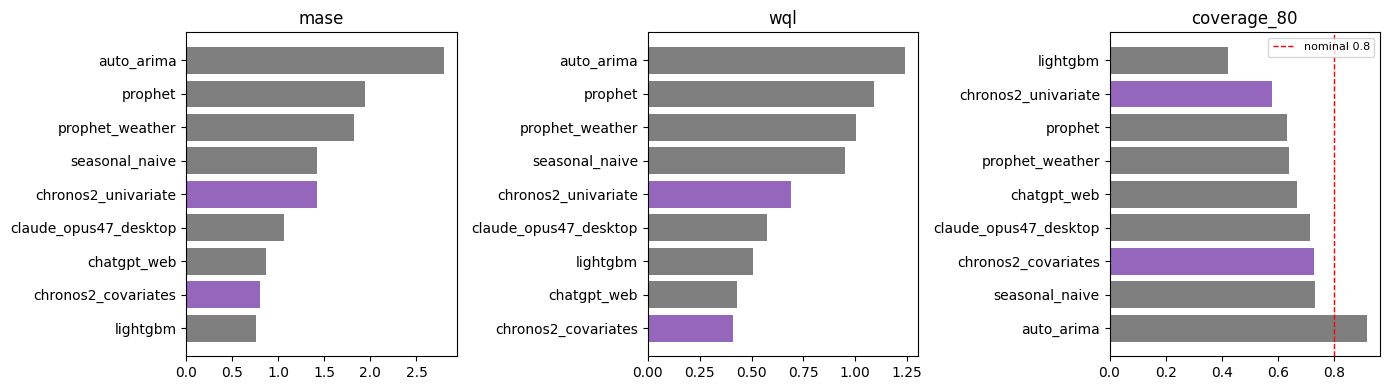

In [5]:
metrics_for_plot = metrics_sorted[metrics_sorted['method'] != 'ollama_llama31']
fig = P.plot_metric_bars(metrics_for_plot, out_path=OUT_FIG / '02_metric_bars.png')
plt.show()

### Forecast vs actual — all methods

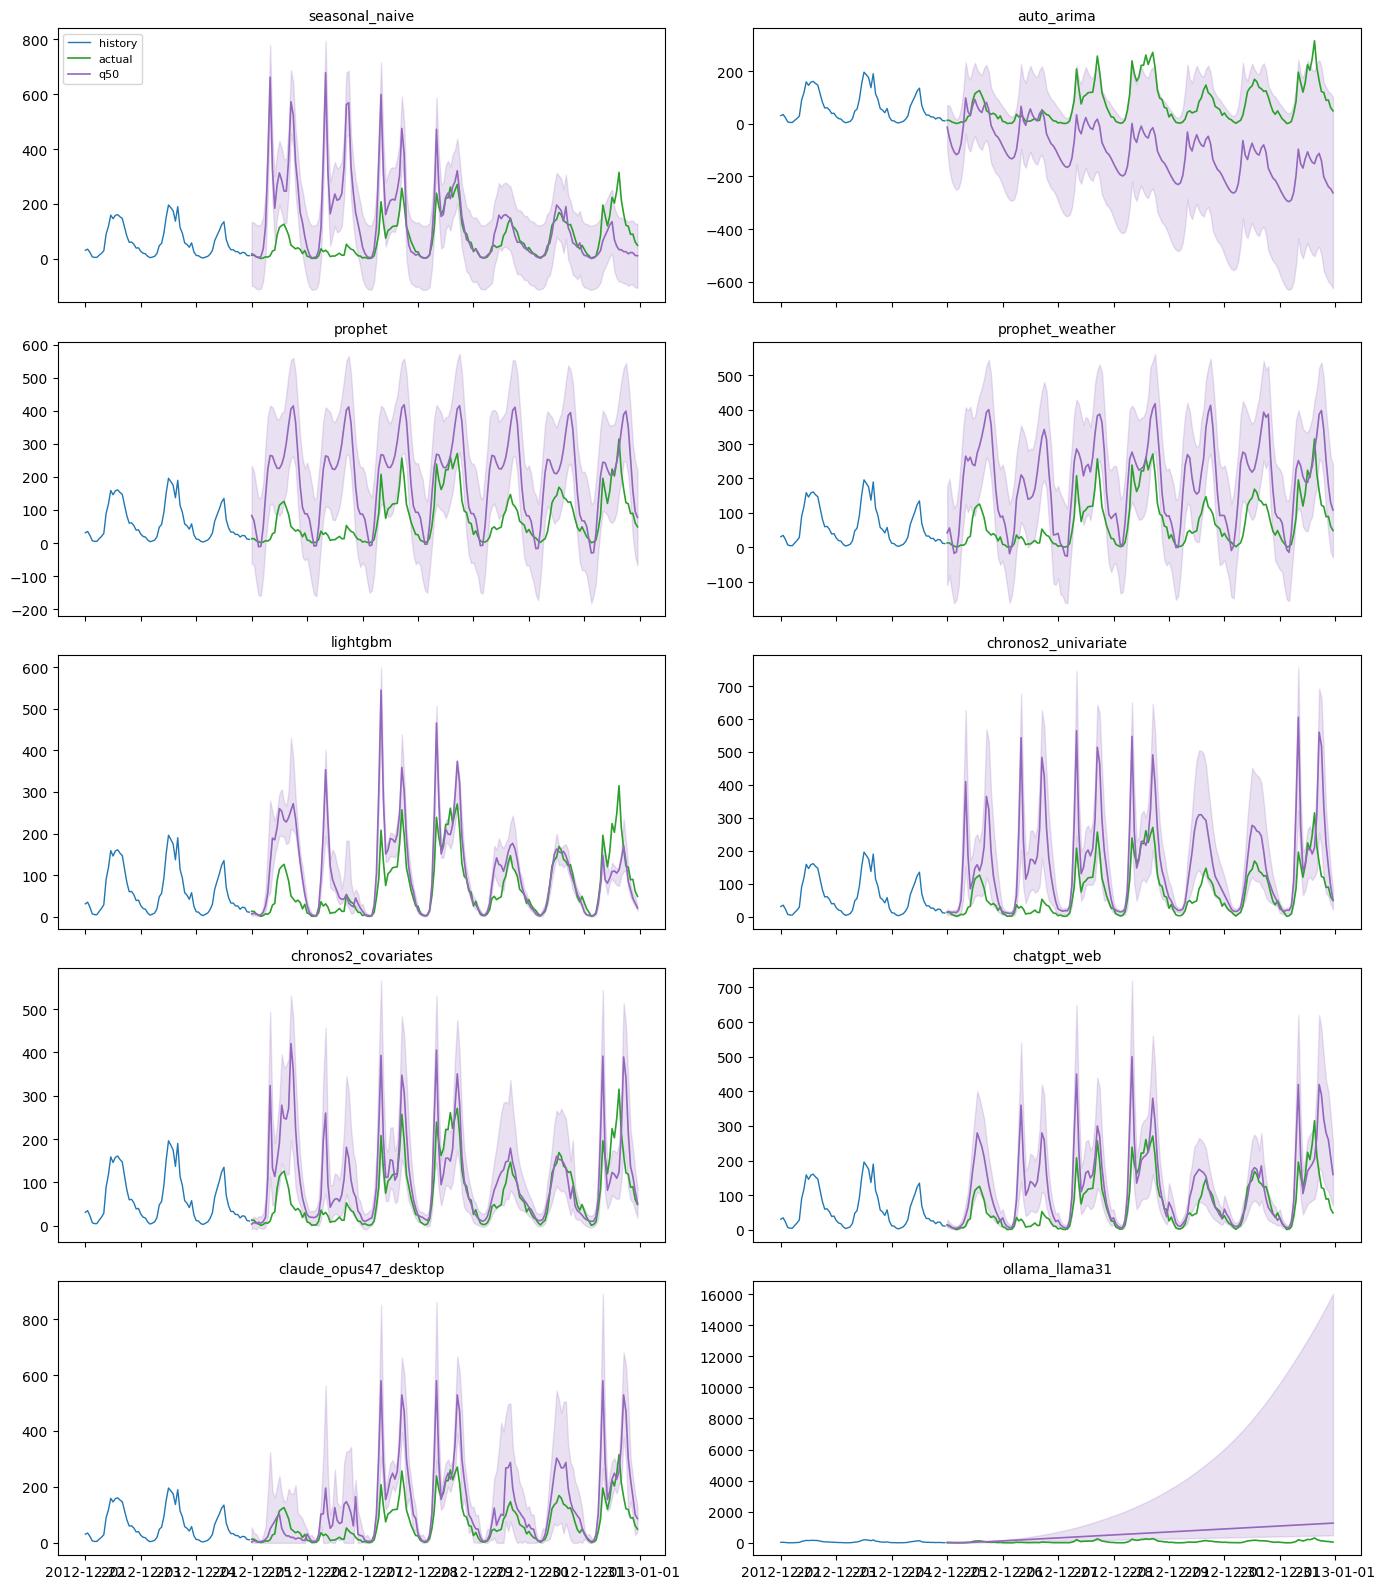

In [6]:
fig = P.plot_all_forecasts(train, forecasts, actuals,
                            out_path=OUT_FIG / '02_all_forecasts.png',
                            history_tail=24*3)
plt.show()

### Chronos-2: univariate vs covariates

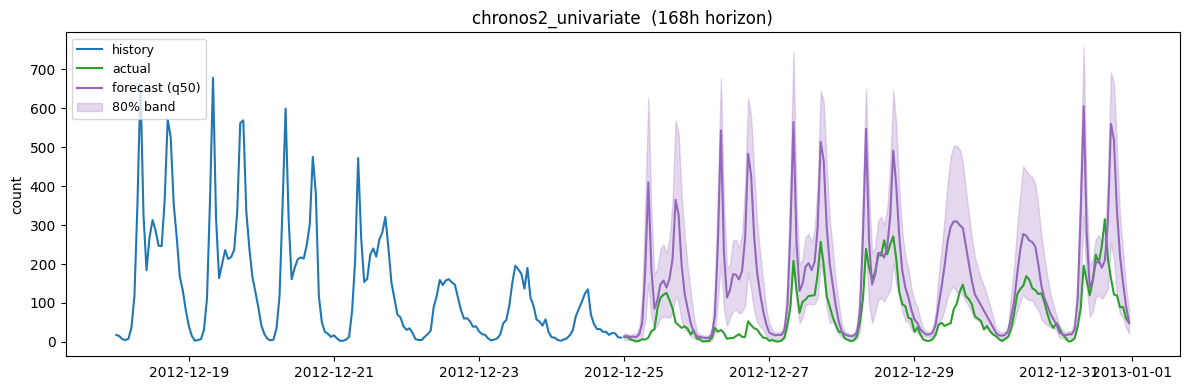

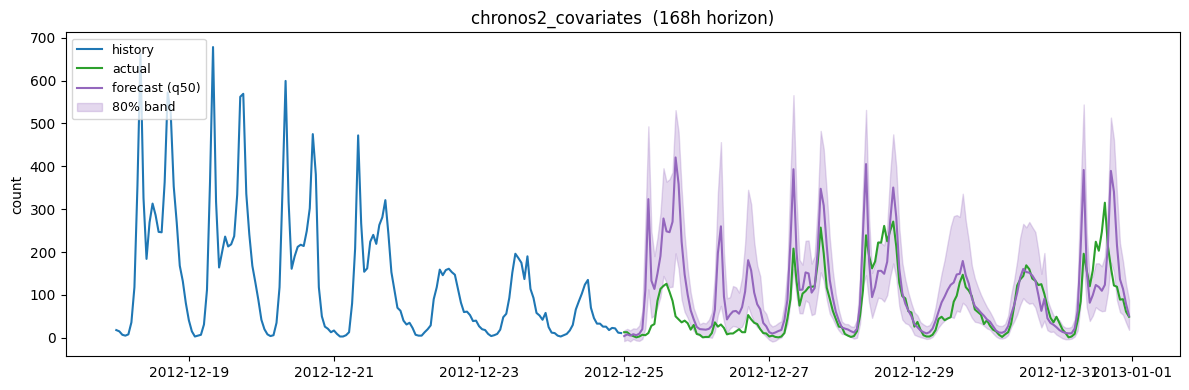

In [7]:
for name in ['chronos2_univariate', 'chronos2_covariates']:
    P.plot_forecast_vs_actual(train, forecasts[name], actuals,
                              title=f'{name}  ({HORIZON}h horizon)',
                              out_path=OUT_FIG / f'02_{name}.png',
                              history_tail=24*7)
plt.show()